# Modelo A - Predicción de viabilidad de obra (Clasificación)

1. Cargue de la base de datos preparada previamente
2. División de los datos 70-30
3. Aprendizaje del Modelo
4. Evaluación del Modelo: matriz de confusion, P,R, ROC
5. Guardar el modelo

* El despliegue se realiza en otro jupyter_notebook

In [2]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de datos


Se carga la base de datos preparada ***BD FINAL TOKENIZACION***

In [3]:
#Cargamos los datos
data = pd.read_excel("BD FINAL TOKENIZACION.xlsx")
data.head()

,CENSO_NUMERO,NOFORMULAR,ESTRATO,AREATOTZC,MANO_OBRAP,MANO_OBRAT,AREAVENDIB,NUMUNIDEST,NRO_EDIFIC,NRO_PISOS,...,SIS_CONSTR_5,SIS_CONSTR_6,SIS_CONSTR_7,OB_FORMAL_1,OB_FORMAL_2,AMPLIACION_1,AMPLIACION_2,USO_DOS_1,USO_DOS_2,USO_DOS_3
0,94,81093,3,0,0,0,120,1,1,1,...,0,0,0,0,1,0,1,0,0,1
1,94,86208,3,0,0,0,130,1,1,1,...,0,0,0,0,1,0,1,0,0,1
2,94,115110,2,0,0,0,48,2,1,1,...,0,0,0,0,1,0,1,0,0,1
3,94,115110,2,0,0,0,96,1,1,1,...,0,0,0,0,1,0,1,0,0,1
4,94,115461,3,0,0,0,184,1,1,1,...,0,0,0,0,1,0,1,0,0,1


In [4]:
#Dummies para las variables predictoras ESTRATO, CAPITULO, RANVIVI, TIPOVRDEST
data = pd.get_dummies(data, columns=['ESTRATO','CAPITULO','RANVIVI'], drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=['TIPOVRDEST'], drop_first=True, dtype=int)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45725 entries, 0 to 45724
Data columns (total 74 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CENSO_NUMERO    45725 non-null  int64  
 1   NOFORMULAR      45725 non-null  int64  
 2   AREATOTZC       45725 non-null  int64  
 3   MANO_OBRAP      45725 non-null  int64  
 4   MANO_OBRAT      45725 non-null  int64  
 5   AREAVENDIB      45725 non-null  int64  
 6   NUMUNIDEST      45725 non-null  int64  
 7   NRO_EDIFIC      45725 non-null  int64  
 8   NRO_PISOS       45725 non-null  int64  
 9   GRADOAVANC      45725 non-null  int64  
 10  PRECIOVTAX      45725 non-null  int64  
 11  AREATOTCO2      45725 non-null  int64  
 12  AREAVENUNI      45725 non-null  int64  
 13  CONS_ID         45725 non-null  int64  
 14  MANO_FINAL      45725 non-null  int64  
 15  UNIDAD_PISO     45725 non-null  float64
 16  VIABLE          45725 non-null  int64  
 17  DPTO_MPIO_5001  45725 non-null 

In [6]:
#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data["VIABLE"]=labelencoder.fit_transform(data["VIABLE"])
data.head()

,CENSO_NUMERO,NOFORMULAR,AREATOTZC,MANO_OBRAP,MANO_OBRAT,AREAVENDIB,NUMUNIDEST,NRO_EDIFIC,NRO_PISOS,GRADOAVANC,...,CAPITULO_5,CAPITULO_6,RANVIVI_0,RANVIVI_1,RANVIVI_2,RANVIVI_3,RANVIVI_4,RANVIVI_5,RANVIVI_6,TIPOVRDEST_2
0,94,81093,0,0,0,120,1,1,1,40,...,0,0,1,0,0,0,0,0,0,1
1,94,86208,0,0,0,130,1,1,1,90,...,0,0,1,0,0,0,0,0,0,1
2,94,115110,0,0,0,48,2,1,1,20,...,0,0,1,0,0,0,0,0,0,1
3,94,115110,0,0,0,96,1,1,1,20,...,0,0,0,0,0,0,1,0,0,1
4,94,115461,0,0,0,184,1,1,1,50,...,0,0,0,0,0,0,0,1,0,1


# 2. División 70-30


**Nota:** Vemos que la base de datos incluye variables de identificación (NOFORMULAR, CENSO_NUMERO y CONS_ID), se decide filtrar estas variables para evitar overfitting y que el modelo se entrene erróneamente.

Adicionalmente, se crea X y Y sin las 3 columnas para que el modelo no se confunda al correr.

<Axes: xlabel='VIABLE'>

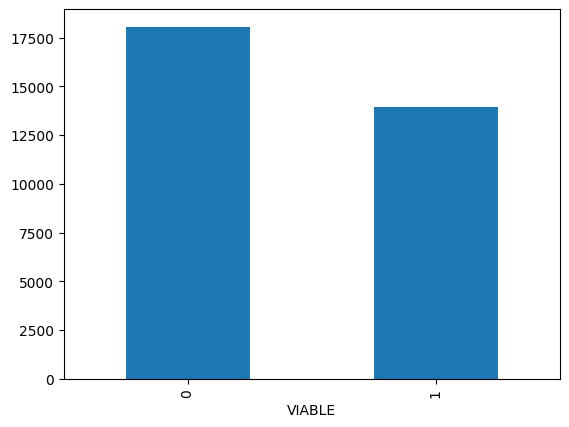

In [7]:
from sklearn.model_selection import train_test_split
columnas_eliminar = ['CENSO_NUMERO', 'CONS_ID', 'NOFORMULAR','OB_FORMAL_2','AMPLIACION_2', 'USO_DOS_2', 'MANO_FINAL', 'MANO_OBRAT']
X = data.drop(columns=columnas_eliminar + ['VIABLE'],axis=1)
Y = data['VIABLE']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y)
Y_train.value_counts().plot(kind='bar')

# 3. Aprendizaje con el 70% y Evaluación con el 30%


Lo aplico a los datos de entrenamiento

# **Tree**
No se normaliza

Aprendizaje (70%)

In [13]:
from sklearn.tree import DecisionTreeClassifier

modelTree = DecisionTreeClassifier(criterion='gini', min_samples_leaf=40, max_depth=5,class_weight='balanced',random_state=42)
modelTree.fit(X_train, Y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=40, random_state=42)

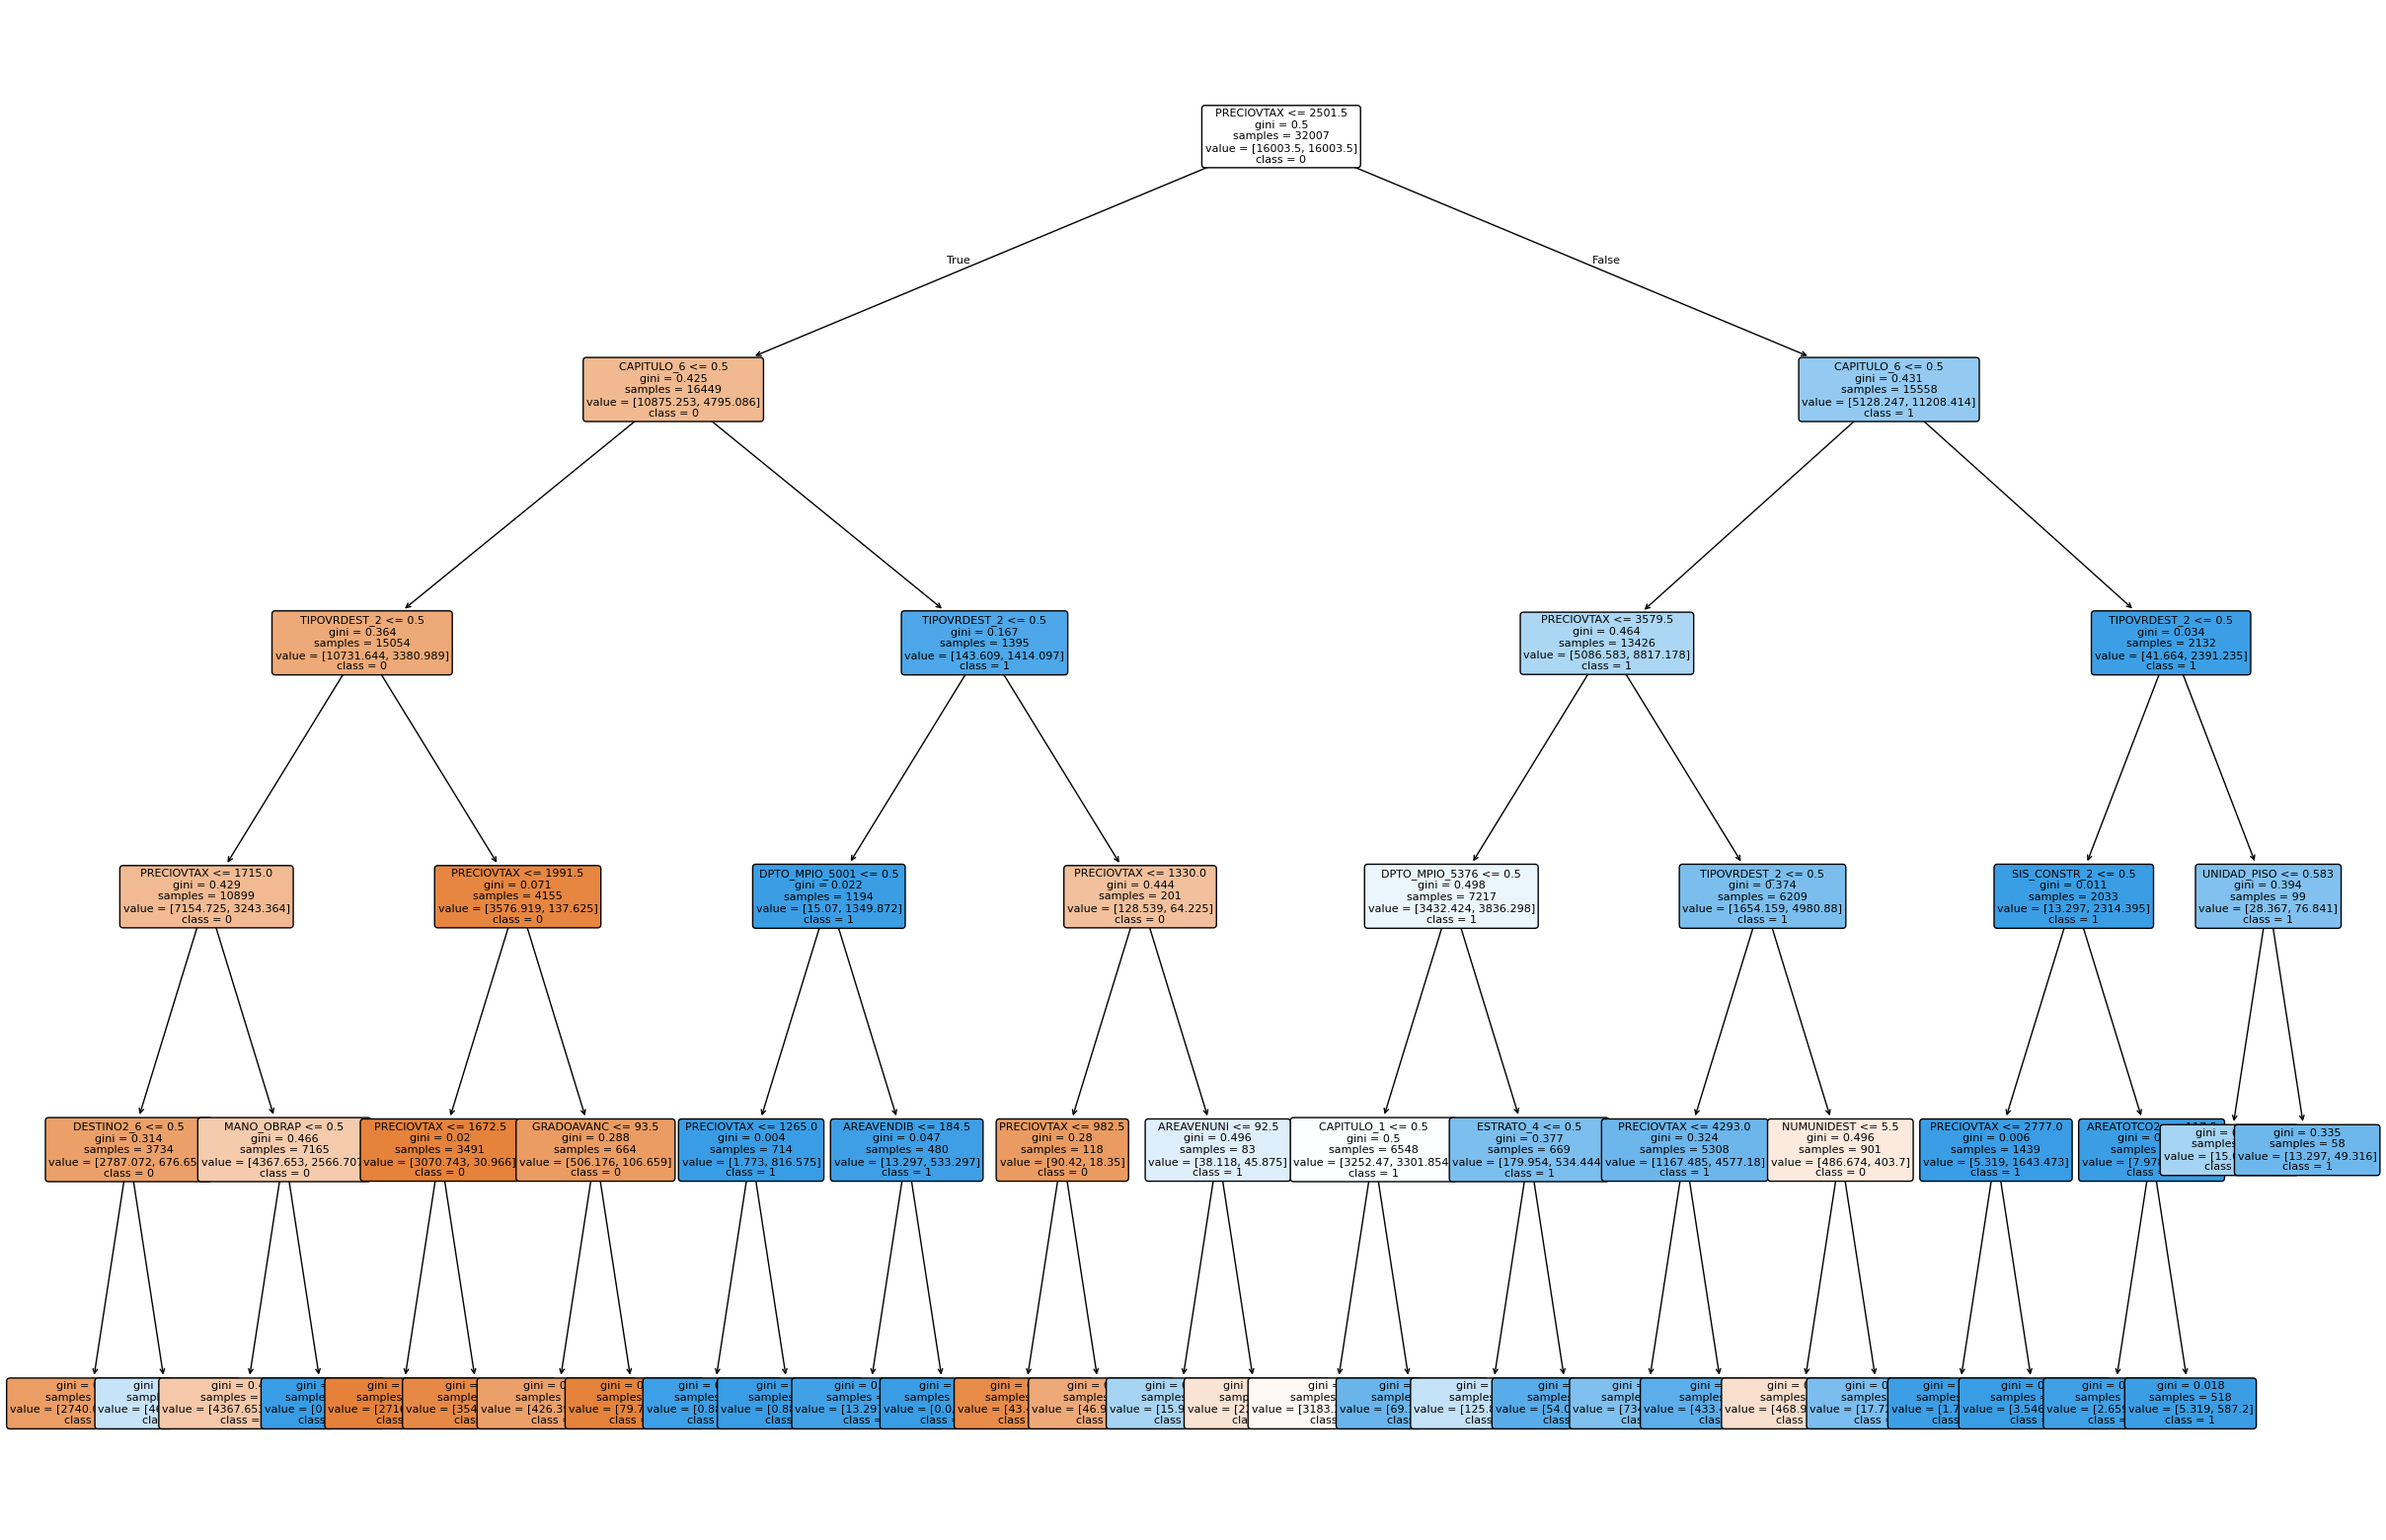

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,20))
plot_tree(modelTree, feature_names=X_train.columns.values, class_names=[str(c) for c in labelencoder.classes_], rounded=True,  fontsize=8, filled=True)
plt.show()

In [15]:
from sklearn import metrics

Y_pred = modelTree.predict(X_test)
print(Y_pred)

[0 1 1 ... 0 1 0]


In [16]:
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.7557953054381105


In [17]:
#Matriz de confusion
from sklearn import metrics

cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
cm

array([[6974,  764],
       [2586, 3394]])

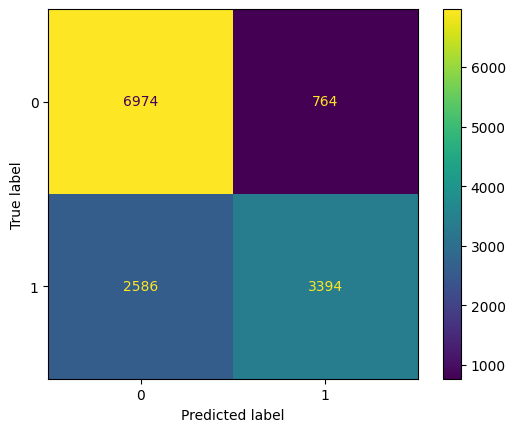

In [18]:
#Plot de la matriz de confusion
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

In [19]:
#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))

              precision    recall  f1-score   support

           0       0.73      0.90      0.81      7738
           1       0.82      0.57      0.67      5980

    accuracy                           0.76     13718
   macro avg       0.77      0.73      0.74     13718
weighted avg       0.77      0.76      0.75     13718



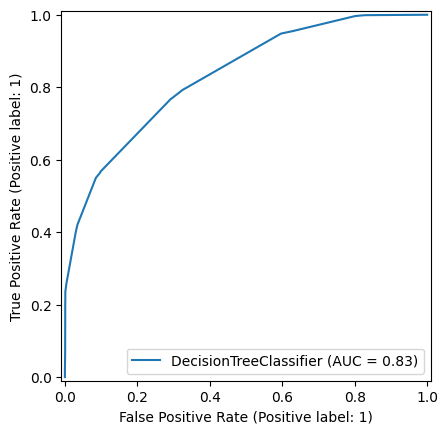

In [20]:
#area ROC
#razon entre FP y VP
metrics.RocCurveDisplay.from_estimator(modelTree,X_test, Y_test)



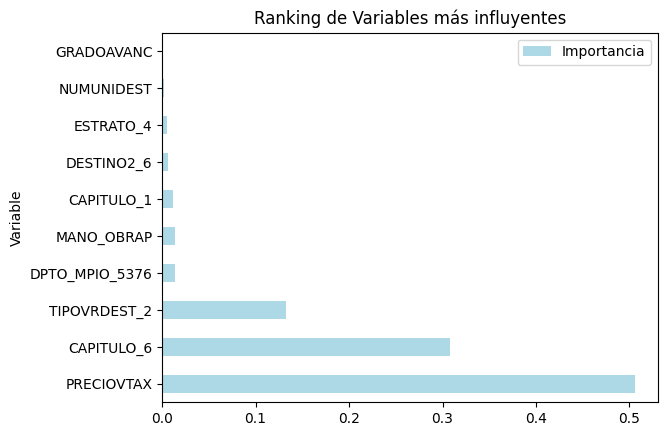

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = modelTree.feature_importances_
nombres_columnas = X.columns

df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

df_importancia.head(10).plot(kind='barh', x='Variable', y='Importancia', color='lightblue')
plt.title('Ranking de Variables más influyentes')
plt.show()

# **KNN**
* Normalización

              precision    recall  f1-score   support

           0       0.73      0.90      0.81      7738
           1       0.82      0.57      0.67      5980

    accuracy                           0.76     13718
   macro avg       0.77      0.73      0.74     13718
weighted avg       0.77      0.76      0.75     13718



,AREATOTZC,MANO_OBRAP,AREAVENDIB,NUMUNIDEST,NRO_EDIFIC,NRO_PISOS,GRADOAVANC,PRECIOVTAX,AREATOTCO2,AREAVENUNI,...,CAPITULO_5,CAPITULO_6,RANVIVI_0,RANVIVI_1,RANVIVI_2,RANVIVI_3,RANVIVI_4,RANVIVI_5,RANVIVI_6,TIPOVRDEST_2
23864,0.000000,0.0,0.018250,0.000,0.0,0.064516,1.000000,0.492424,0.013590,0.715447,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2606,0.002126,0.0,0.033285,0.020,0.0,0.129032,0.646465,0.121212,0.026407,0.247967,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5814,0.000810,0.0,0.012028,0.005,0.0,0.032258,0.393939,0.189394,0.009575,0.227642,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
26891,0.000000,0.0,0.006844,0.000,0.0,0.032258,0.444444,0.166667,0.005096,0.268293,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
18867,0.003644,0.0,0.035255,0.015,0.0,0.096774,0.868687,0.356061,0.029033,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


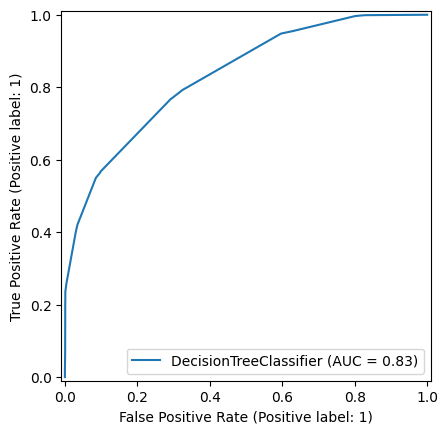

In [22]:
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))


metrics.RocCurveDisplay.from_estimator(modelTree,X_test, Y_test)

#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
variables_numericas=['AREATOTZC','MANO_OBRAP','AREAVENDIB','NUMUNIDEST','NRO_EDIFIC','NRO_PISOS',
                     'GRADOAVANC','PRECIOVTAX','AREATOTCO2','AREAVENUNI','UNIDAD_PISO','DPTO_MPIO_5001',
                     'DPTO_MPIO_5079','DPTO_MPIO_5088','DPTO_MPIO_5129','DPTO_MPIO_5148','DPTO_MPIO_5212','DPTO_MPIO_5266',
                     'DPTO_MPIO_5308','DPTO_MPIO_5318','DPTO_MPIO_5360','DPTO_MPIO_5376','DPTO_MPIO_5380','DPTO_MPIO_5400',
                     'DPTO_MPIO_5440','DPTO_MPIO_5607','DPTO_MPIO_5615','DPTO_MPIO_5631','DESTINO2_1','DESTINO2_2','DESTINO2_3',
                     'DESTINO2_4','DESTINO2_5','DESTINO2_6','SIS_CONSTR_1','SIS_CONSTR_2','SIS_CONSTR_3','SIS_CONSTR_4','SIS_CONSTR_5','SIS_CONSTR_6','SIS_CONSTR_7',
                     'OB_FORMAL_1','AMPLIACION_1','USO_DOS_1','ESTRATO_1',
                     'ESTRATO_2','ESTRATO_3','ESTRATO_4','ESTRATO_5','ESTRATO_6','CAPITULO_1','CAPITULO_2','CAPITULO_3',
                     'CAPITULO_4','CAPITULO_5','CAPITULO_6','RANVIVI_0','RANVIVI_1','RANVIVI_2','RANVIVI_3','RANVIVI_4','RANVIVI_5',
                     'RANVIVI_6','TIPOVRDEST_2']


min_max_scaler.fit(data[variables_numericas])

#Se aplica la normalización a 70%  y 30%
X_train[variables_numericas]= min_max_scaler.transform(X_train[variables_numericas])
X_test[variables_numericas]= min_max_scaler.transform(X_test[variables_numericas])
X_train.head()


In [23]:
#Aprendizaje KNN con 70%
from sklearn.neighbors  import KNeighborsClassifier

modelKnn = KNeighborsClassifier(n_neighbors=4, metric='euclidean')
modelKnn.fit(X_train, Y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=4)

              precision    recall  f1-score   support

           0       0.77      0.92      0.84      7738
           1       0.87      0.65      0.74      5980

    accuracy                           0.81     13718
   macro avg       0.82      0.79      0.79     13718
weighted avg       0.82      0.81      0.80     13718



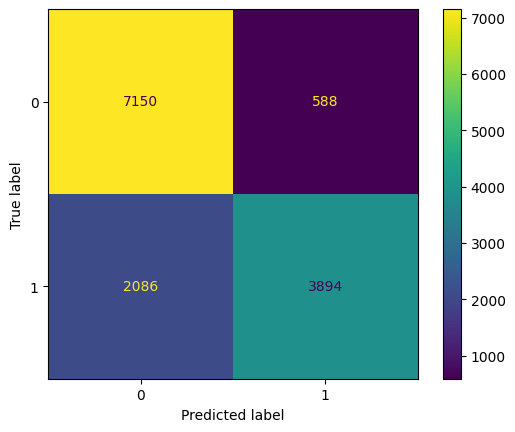

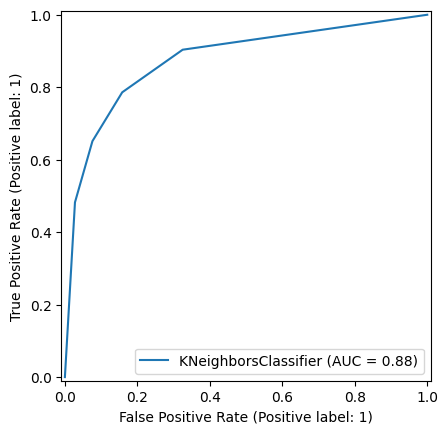

In [24]:
#Evaluación de Knn con 30%

from sklearn import metrics
Y_pred = modelKnn.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[str(c) for c in labelencoder.classes_])
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelKnn,X_test, Y_test)


# **Red Neuronal**
- Normalizar

In [25]:
from sklearn.neural_network import MLPClassifier
modelNN = MLPClassifier(activation="logistic",hidden_layer_sizes=(50), learning_rate='constant',
                     learning_rate_init=0.05, momentum= 0.02, max_iter=5000, random_state=45)

modelNN.fit(X_train, Y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=50,
              learning_rate_init=0.05, max_iter=5000, momentum=0.02,
              random_state=45)

              precision    recall  f1-score   support

           0       0.80      0.86      0.83      7738
           1       0.79      0.72      0.76      5980

    accuracy                           0.80     13718
   macro avg       0.80      0.79      0.79     13718
weighted avg       0.80      0.80      0.80     13718



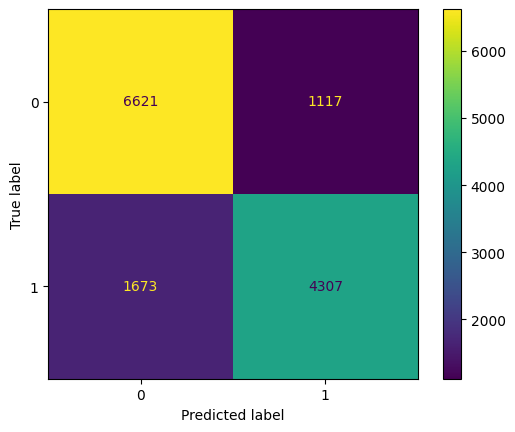

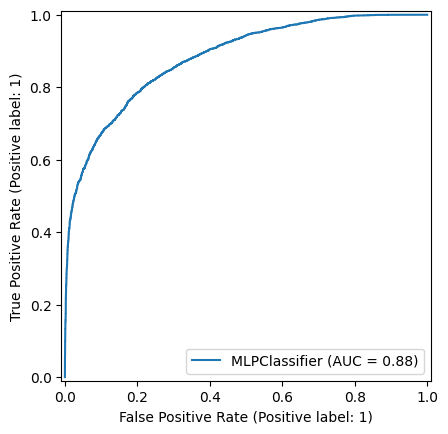

In [26]:
from sklearn import metrics

Y_pred = modelNN.predict(X_test)

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[str(c) for c in labelencoder.classes_])
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelNN,X_test, Y_test)

# **SVM**
-Normalizar

In [27]:
#SVM
from sklearn.svm import SVC # SVR

modelSVM = SVC(kernel='linear') #'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%

KeyboardInterrupt: 

              precision    recall  f1-score   support

           0       0.71      0.80      0.75      7738
           1       0.69      0.57      0.63      5980

    accuracy                           0.70     13718
   macro avg       0.70      0.69      0.69     13718
weighted avg       0.70      0.70      0.70     13718



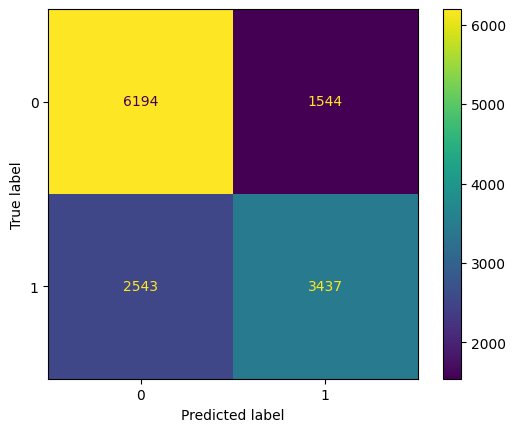

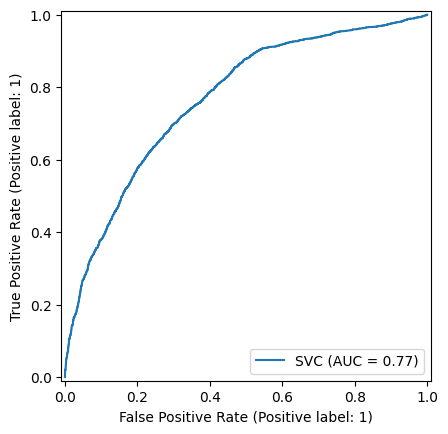

In [13]:
#Evaluación de SVM
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[str(c) for c in labelencoder.classes_])
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=[str(c) for c in labelencoder.classes_]))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelSVM,X_test, Y_test)

# 5. Guardamos el mejor modelo
Se entrena modelo final con 100% de los datos (X,Y)

In [28]:
#Normalizar X en caso de ser necesario: Knn, NN, SVM, Reg. Se debe guardar el modelo de normalización porque los datos futuros los debo normalizar.
X[variables_numericas]= min_max_scaler.transform(X[variables_numericas])

Seleccionamos el modelo de **RED NEURONAL**

In [29]:
#Entrenamos modelo final - YO COLOCO EL QUE ELEGÍ COMO MEJOR MODELO
#Como guardé Red neuronal lo debo normalizar
modelNN.fit(X, Y) #100%

MLPClassifier(activation='logistic', hidden_layer_sizes=50,
              learning_rate_init=0.05, max_iter=5000, momentum=0.02,
              random_state=45)

Importamos el modelo seleccionado para el despliegue

In [30]:
import pickle
filename = 'modelo-class.pkl'
variables= X.columns._values
pickle.dump([modelNN, labelencoder,variables,min_max_scaler], open(filename, 'wb'))


Para el despliegue del modelo, no tiene sentido solicitarle al usuario 50 variables, entonces se utiliza la herramienta de la librería que calcula la importancia de las variables

In [35]:
from sklearn.inspection import permutation_importance

result = permutation_importance(modelNN, X_test, Y_test,
                                n_repeats=10,random_state=42,scoring='roc_auc')

importancias= pd.DataFrame({'Variable': X.columns,'Importancia': result.importances_mean,'Desviacion': result.importances_std}).sort_values('Importancia',ascending=False)

print(importancias.head(20).to_string(index=False))

      Variable  Importancia  Desviacion
    PRECIOVTAX     0.144590    0.002247
  TIPOVRDEST_2     0.063155    0.001478
    CAPITULO_3     0.050299    0.000780
    CAPITULO_6     0.047836    0.001457
    GRADOAVANC     0.037446    0.001329
   OB_FORMAL_1     0.034603    0.001016
  AMPLIACION_1     0.032375    0.001073
     ESTRATO_3     0.026909    0.000603
    CAPITULO_2     0.024988    0.001042
     RANVIVI_6     0.024530    0.001322
     USO_DOS_1     0.022889    0.001039
     USO_DOS_3     0.022583    0.001014
  SIS_CONSTR_1     0.021592    0.001084
     ESTRATO_2     0.021500    0.000623
    DESTINO2_1     0.020833    0.000567
    CAPITULO_4     0.018681    0.000928
     ESTRATO_4     0.018671    0.000717
     RANVIVI_5     0.017679    0.000683
    DESTINO2_3     0.017007    0.000748
DPTO_MPIO_5376     0.017004    0.000578
